In [1]:
import pandas as pd
import numpy as np
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt

project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'experiments' / 'utils').exists()), None)
if project_root is None:
    raise RuntimeError('Project root not found from current working directory.')
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from experiments.utils.confidence_intervals import round_metrics_with_ci_table, summarize_metrics_with_ci

In [2]:
fp32_path = "../../../full_precision/forgeting/experiments"


# Attack forg ep

In [3]:
expath = '../attack_forg_ep'
# results dataset
df = pd.read_parquet(os.path.join(expath,'attack_forg_ep.parquet'))

# attach also fp32
df_fp32 = pd.read_parquet(os.path.join(fp32_path, "attack_forg_ep/attack_forg_ep.parquet")) [['prefix_250', 'prefix_200', 'prefix_150', 'prefix_100', 'suffix',
       '15b_ep0', '15b_ep0_em', '15b_ep0_bleu', '15b_ep0_meteor',
       '15b_ep0_rougeL', '15b_ep1', '15b_ep1_em', '15b_ep1_bleu',
       '15b_ep1_meteor', '15b_ep1_rougeL', '15b_ep2', '15b_ep2_em',
       '15b_ep2_bleu', '15b_ep2_meteor', '15b_ep2_rougeL', '15b_ep3',
       '15b_ep3_em', '15b_ep3_bleu', '15b_ep3_meteor', '15b_ep3_rougeL']]

merged_df = pd.merge(df, df_fp32,
  on=['prefix_250', 'prefix_200',
  'prefix_150', 'prefix_100', 'suffix'],
  how='inner')


## fp32

In [4]:
# Extract means + confidence intervals
metrics = ['em', 'bleu', 'meteor', 'rougeL']
eps = ['ep0', 'ep1', 'ep2', 'ep3']

ep_fp32_absolute_ci = summarize_metrics_with_ci(
    merged_df,
    row_values=eps,
    metrics=metrics,
    column_name_fn=lambda ep, metric: f'15b_{ep}_{metric}',
)
ep_fp32_absolute = ep_fp32_absolute_ci[metrics].copy()
ep_fp32_absolute_ci = round_metrics_with_ci_table(ep_fp32_absolute_ci, decimals=3)
ep_fp32_absolute_ci

,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
ep0,0.455,"[0.424, 0.486]",71.477,"[69.353, 73.563]",0.759,"[0.741, 0.778]",0.739,"[0.719, 0.758]"
ep1,0.145,"[0.125, 0.168]",52.553,"[50.504, 54.636]",0.613,"[0.595, 0.632]",0.583,"[0.563, 0.603]"
ep2,0.143,"[0.123, 0.166]",53.086,"[51.041, 55.093]",0.619,"[0.6, 0.637]",0.586,"[0.566, 0.605]"
ep3,0.155,"[0.134, 0.179]",54.477,"[52.407, 56.502]",0.629,"[0.611, 0.648]",0.596,"[0.577, 0.615]"


### bf16

In [5]:
# Extract means + confidence intervals
metrics = ['em', 'bleu', 'meteor', 'rougeL']
eps = ['ep0', 'ep1', 'ep2', 'ep3']

ep_bf16_absolute_ci = summarize_metrics_with_ci(
    df,
    row_values=eps,
    metrics=metrics,
    column_name_fn=lambda ep, metric: f'bf16_{ep}_{metric}',
)
ep_bf16_absolute = ep_bf16_absolute_ci[metrics].copy()
ep_bf16_absolute_ci = round_metrics_with_ci_table(ep_bf16_absolute_ci, decimals=3)
ep_bf16_absolute_ci

,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
ep0,0.453,"[0.422, 0.484]",71.364,"[69.234, 73.439]",0.759,"[0.74, 0.778]",0.739,"[0.719, 0.758]"
ep1,0.142,"[0.122, 0.165]",52.466,"[50.405, 54.526]",0.613,"[0.595, 0.632]",0.583,"[0.563, 0.603]"
ep2,0.139,"[0.119, 0.162]",53.132,"[51.072, 55.135]",0.619,"[0.6, 0.637]",0.586,"[0.567, 0.606]"
ep3,0.155,"[0.134, 0.179]",54.437,"[52.372, 56.454]",0.629,"[0.611, 0.647]",0.596,"[0.576, 0.615]"


In [6]:
# With the baseline
first = ep_bf16_absolute.iloc[0]

ep_bf16_baseline = ep_bf16_absolute.subtract(first)
ep_bf16_baseline

,em,bleu,meteor,rougeL
ep0,0.000,0.000000,0.000000,0.000000
ep1,-0.311,-18.898456,-0.145510,-0.155369
ep2,-0.314,-18.232098,-0.140155,-0.152197
ep3,-0.298,-16.927624,-0.130010,-0.143010


## int8

In [7]:
# Extract means + confidence intervals
metrics = ['em', 'bleu', 'meteor', 'rougeL']
eps = ['ep0', 'ep1', 'ep2', 'ep3']

ep_i8_absolute_ci = summarize_metrics_with_ci(
    df,
    row_values=eps,
    metrics=metrics,
    column_name_fn=lambda ep, metric: f'i8_{ep}_{metric}',
)
ep_i8_absolute = ep_i8_absolute_ci[metrics].copy()
ep_i8_absolute_ci = round_metrics_with_ci_table(ep_i8_absolute_ci, decimals=3)
ep_i8_absolute_ci

,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
ep0,0.457,"[0.426, 0.488]",71.245,"[69.113, 73.3]",0.757,"[0.739, 0.776]",0.737,"[0.717, 0.757]"
ep1,0.136,"[0.116, 0.159]",52.116,"[50.101, 54.16]",0.612,"[0.594, 0.631]",0.579,"[0.56, 0.599]"
ep2,0.132,"[0.112, 0.154]",52.575,"[50.551, 54.595]",0.614,"[0.595, 0.632]",0.583,"[0.564, 0.602]"
ep3,0.155,"[0.134, 0.179]",53.881,"[51.808, 55.918]",0.624,"[0.606, 0.643]",0.590,"[0.571, 0.609]"


## i4

In [8]:
# Extract means + confidence intervals
metrics = ['em', 'bleu', 'meteor', 'rougeL']
eps = ['ep0', 'ep1', 'ep2', 'ep3']

ep_i4_absolute_ci = summarize_metrics_with_ci(
    df,
    row_values=eps,
    metrics=metrics,
    column_name_fn=lambda ep, metric: f'i4_{ep}_{metric}',
)
ep_i4_absolute = ep_i4_absolute_ci[metrics].copy()
ep_i4_absolute_ci = round_metrics_with_ci_table(ep_i4_absolute_ci, decimals=3)
ep_i4_absolute_ci

,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
ep0,0.410,"[0.38, 0.441]",69.364,"[67.245, 71.414]",0.742,"[0.723, 0.76]",0.719,"[0.699, 0.738]"
ep1,0.132,"[0.112, 0.154]",50.570,"[48.516, 52.603]",0.599,"[0.581, 0.618]",0.565,"[0.546, 0.585]"
ep2,0.135,"[0.115, 0.158]",51.264,"[49.21, 53.269]",0.604,"[0.585, 0.622]",0.570,"[0.551, 0.59]"
ep3,0.144,"[0.124, 0.167]",51.914,"[49.887, 53.949]",0.606,"[0.588, 0.625]",0.572,"[0.553, 0.592]"


## Visuals


In [9]:
df_ep_mem_plot = pd.DataFrame({ 'fp32': ep_fp32_absolute['em'],
                                'bf16': ep_bf16_absolute['em'],
                               'i8': ep_i8_absolute['em'],
                               'i4': ep_i4_absolute['em']})
df_ep_mem_plot

,fp32,bf16,i8,i4
ep0,0.455,0.453,0.457,0.410
ep1,0.145,0.142,0.136,0.132
ep2,0.143,0.139,0.132,0.135
ep3,0.155,0.155,0.155,0.144


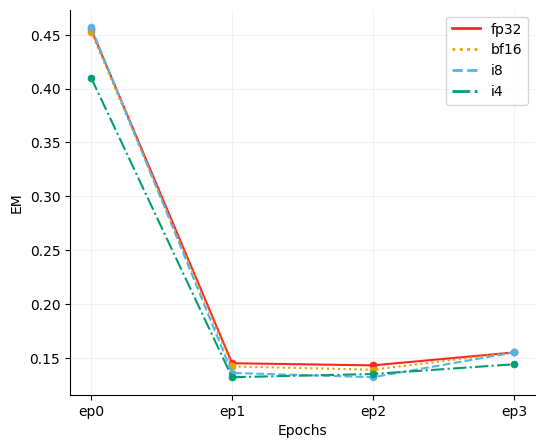

In [10]:
from matplotlib.lines import Line2D
from cycler import cycler

legend_elements = [Line2D([0], [0], lw=2, label='fp32', color='#FF2525', linestyle='-'),
                    Line2D([0], [0], lw=2, label='bf16', color='#E69F00', linestyle=':'),
                   Line2D([0], [0], lw=2, label='i8', color='#56B4E9', linestyle='--'),
                   Line2D([0], [0], lw=2, label='i4', color='#009E73', linestyle='-.')]


fig, ax = plt.subplots(figsize=(6, 5))

# Define colors and linestyles to match legend
labels = ['fp32', 'bf16', 'i8', 'i4']
colors = ['#FF2525', '#E69F00', '#56B4E9', '#009E73']
linestyles = ['-', ':', '--', '-.']
markers = ['o', 'o', 'o', 'o']

for i, label in enumerate(labels):
    # Line
    ax.plot(df_ep_mem_plot.index, df_ep_mem_plot[label], label=label,
            color=colors[i], linestyle=linestyles[i], marker=markers[i],
            markeredgewidth=0.5, markersize=5)

# Hide the all but the bottom spines (axis lines)
ax.spines["right"].set_visible(False)
#ax.spines["left"].set_visible(False)
ax.spines["top"].set_visible(False)

#ax.set_title('Data extraction attack through epochs')

ax.set_xlabel('Epochs')
ax.set_ylabel('EM')
plt.legend(frameon=True, handles=legend_elements)
plt.grid(axis='both', color='0.95', linestyle='-')



plt.show()
fig.savefig('./quant_attack_forg_ep.pdf', format='pdf')

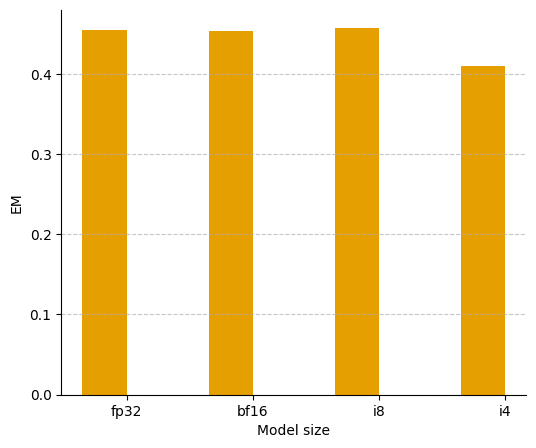

In [11]:
#"#E69F00", "#56B4E9", "#009E73", "#0072B2", "#D55E00", "#CC79A7", "#F0E442"
ep0 = df_ep_mem_plot.T['ep0']

indices = range(len(ep0))
names = df_ep_mem_plot.T.index

# Calculate optimal width
width = 0.35  # Adjusted to be constant and easy to manage

fig, ax = plt.subplots(figsize=(6, 5))

# Plot bars with single color
bar1 = ax.bar(np.array(indices) - width/2, ep0, width, label='pre-train', color='#E69F00')

# Set the x-ticks and x-tick labels
ax.set_xticks(indices)
ax.set_xticklabels(names)

# Add labels and title
ax.set_xlabel('Model size')
ax.set_ylabel('EM')
# Hide the all but the bottom spines (axis lines)
ax.spines["right"].set_visible(False)
#ax.spines["left"].set_visible(False)
ax.spines["top"].set_visible(False)

#ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=6)
ax.grid(axis='y', linestyle='--', alpha=0.7)



plt.show()
fig.savefig('./quant_attack_forget_msize_pre-train.pdf', format='pdf')

# Attack forg plen

In [12]:
expath = '../attack_forg_plen'
# results dataset
df = pd.read_parquet(os.path.join(expath,'attack_forg_plen.parquet'))

# attach also fp32
df_fp32 = pd.read_parquet(os.path.join(fp32_path, "attack_forg_plen/attack_forg_plen.parquet"))

merged_df = pd.merge(df, df_fp32,
  on=['prefix_250', 'prefix_200',
  'prefix_150', 'prefix_100', 'suffix'],
  how='inner')

## fp32

In [13]:
# Extract means + confidence intervals
metrics = ['em', 'bleu', 'meteor', 'rougeL']
plens = ['p100', 'p150', 'p200', 'p250']
eps = ['ep0', 'ep3']

plen_fp32_absolute_ci = summarize_metrics_with_ci(
    merged_df,
    row_values=plens,
    metrics=metrics,
    column_name_fn=lambda plen, metric: f'15b_{eps[1]}_{plen}_{metric}',
)
plen_fp32_absolute = plen_fp32_absolute_ci[metrics].copy()
plen_fp32_absolute_ci = round_metrics_with_ci_table(plen_fp32_absolute_ci, decimals=3)
plen_fp32_absolute_ci

,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
p100,0.155,"[0.134, 0.179]",54.477,"[52.467, 56.496]",0.629,"[0.611, 0.648]",0.596,"[0.577, 0.615]"
p150,0.198,"[0.174, 0.224]",57.748,"[55.665, 59.8]",0.657,"[0.639, 0.675]",0.625,"[0.605, 0.644]"
p200,0.220,"[0.195, 0.247]",59.912,"[57.816, 61.944]",0.675,"[0.657, 0.694]",0.646,"[0.626, 0.665]"
p250,0.235,"[0.21, 0.262]",61.837,"[59.75, 63.861]",0.687,"[0.669, 0.706]",0.660,"[0.641, 0.679]"


In [14]:
# With the baseline

plen_fp32_ep0_ci = summarize_metrics_with_ci(
    merged_df,
    row_values=plens,
    metrics=metrics,
    column_name_fn=lambda plen, metric: f'15b_{eps[0]}_{plen}_{metric}',
)
plen_fp32_ep0 = plen_fp32_ep0_ci[metrics].copy()
plen_fp32_ep0_ci = round_metrics_with_ci_table(plen_fp32_ep0_ci, decimals=3)
plen_fp32_baseline = plen_fp32_absolute.subtract(plen_fp32_ep0)
plen_fp32_baseline

,em,bleu,meteor,rougeL
p100,-0.300,-17.000262,-0.130486,-0.142932
p150,-0.308,-17.993250,-0.134765,-0.150294
p200,-0.316,-17.756623,-0.130953,-0.148597
p250,-0.314,-17.094791,-0.131974,-0.144755


In [15]:
plen_fp32_ep0_ci

,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
p100,0.455,"[0.424, 0.486]",71.477,"[69.353, 73.563]",0.759,"[0.741, 0.778]",0.739,"[0.719, 0.758]"
p150,0.506,"[0.475, 0.537]",75.741,"[73.717, 77.688]",0.792,"[0.774, 0.809]",0.775,"[0.756, 0.794]"
p200,0.536,"[0.505, 0.567]",77.669,"[75.722, 79.592]",0.806,"[0.788, 0.824]",0.794,"[0.776, 0.812]"
p250,0.549,"[0.518, 0.58]",78.932,"[77.013, 80.84]",0.819,"[0.802, 0.836]",0.805,"[0.787, 0.823]"


## bf16

In [16]:
# Extract means + confidence intervals
metrics = ['em', 'bleu', 'meteor', 'rougeL']
plens = ['p100', 'p150', 'p200', 'p250']
eps = ['ep0', 'ep3']

plen_bf16_absolute_ci = summarize_metrics_with_ci(
    merged_df,
    row_values=plens,
    metrics=metrics,
    column_name_fn=lambda plen, metric: f'bf16_{eps[1]}_{plen}_{metric}',
)
plen_bf16_absolute = plen_bf16_absolute_ci[metrics].copy()
plen_bf16_absolute_ci = round_metrics_with_ci_table(plen_bf16_absolute_ci, decimals=3)
plen_bf16_absolute_ci

,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
p100,0.155,"[0.134, 0.179]",54.437,"[52.458, 56.448]",0.629,"[0.611, 0.648]",0.596,"[0.577, 0.615]"
p150,0.198,"[0.174, 0.224]",57.761,"[55.711, 59.783]",0.658,"[0.64, 0.676]",0.625,"[0.606, 0.645]"
p200,0.221,"[0.196, 0.248]",59.998,"[57.894, 62.022]",0.676,"[0.657, 0.694]",0.646,"[0.626, 0.665]"
p250,0.236,"[0.211, 0.263]",61.937,"[59.845, 63.967]",0.688,"[0.67, 0.706]",0.661,"[0.642, 0.68]"


In [17]:
# With the baseline

plen_bf16_ep0_ci = summarize_metrics_with_ci(
    merged_df,
    row_values=plens,
    metrics=metrics,
    column_name_fn=lambda plen, metric: f'bf16_{eps[0]}_{plen}_{metric}',
)
plen_bf16_ep0 = plen_bf16_ep0_ci[metrics].copy()
plen_bf16_ep0_ci = round_metrics_with_ci_table(plen_bf16_ep0_ci, decimals=3)
plen_bf16_baseline = plen_bf16_absolute.subtract(plen_bf16_ep0)
plen_bf16_baseline

,em,bleu,meteor,rougeL
p100,-0.298,-16.927624,-0.130010,-0.143010
p150,-0.310,-18.178197,-0.135240,-0.150577
p200,-0.314,-17.580365,-0.130534,-0.147454
p250,-0.315,-16.987868,-0.131514,-0.143981


In [18]:
plen_bf16_ep0_ci

,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
p100,0.453,"[0.422, 0.484]",71.364,"[69.234, 73.439]",0.759,"[0.74, 0.778]",0.739,"[0.719, 0.758]"
p150,0.508,"[0.477, 0.539]",75.939,"[73.927, 77.889]",0.793,"[0.775, 0.811]",0.776,"[0.757, 0.795]"
p200,0.535,"[0.504, 0.566]",77.579,"[75.615, 79.499]",0.806,"[0.789, 0.824]",0.793,"[0.775, 0.811]"
p250,0.551,"[0.52, 0.582]",78.925,"[76.988, 80.842]",0.819,"[0.802, 0.836]",0.805,"[0.787, 0.823]"


## i8

In [19]:
# Extract means + confidence intervals
metrics = ['em', 'bleu', 'meteor', 'rougeL']
plens = ['p100', 'p150', 'p200', 'p250']
eps = ['ep0', 'ep3']

plen_i8_absolute_ci = summarize_metrics_with_ci(
    merged_df,
    row_values=plens,
    metrics=metrics,
    column_name_fn=lambda plen, metric: f'i8_{eps[1]}_{plen}_{metric}',
)
plen_i8_absolute = plen_i8_absolute_ci[metrics].copy()
plen_i8_absolute_ci = round_metrics_with_ci_table(plen_i8_absolute_ci, decimals=3)
plen_i8_absolute_ci

,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
p100,0.155,"[0.134, 0.179]",53.881,"[51.901, 55.889]",0.624,"[0.606, 0.643]",0.590,"[0.57, 0.609]"
p150,0.191,"[0.168, 0.217]",57.544,"[55.472, 59.595]",0.655,"[0.637, 0.674]",0.624,"[0.604, 0.643]"
p200,0.211,"[0.187, 0.237]",59.886,"[57.798, 61.919]",0.677,"[0.658, 0.695]",0.645,"[0.625, 0.664]"
p250,0.225,"[0.2, 0.252]",61.411,"[59.32, 63.432]",0.684,"[0.666, 0.702]",0.659,"[0.639, 0.678]"


In [20]:
# With the baseline

plen_i8_ep0_ci = summarize_metrics_with_ci(
    merged_df,
    row_values=plens,
    metrics=metrics,
    column_name_fn=lambda plen, metric: f'i8_{eps[0]}_{plen}_{metric}',
)
plen_i8_ep0 = plen_i8_ep0_ci[metrics].copy()
plen_i8_ep0_ci = round_metrics_with_ci_table(plen_i8_ep0_ci, decimals=3)
plen_i8_baseline = plen_i8_absolute.subtract(plen_i8_ep0)
plen_i8_baseline

,em,bleu,meteor,rougeL
p100,-0.302,-17.364048,-0.133186,-0.147465
p150,-0.309,-17.605534,-0.131967,-0.147084
p200,-0.326,-17.830586,-0.131785,-0.150515
p250,-0.321,-17.293742,-0.132451,-0.143217


In [21]:
plen_i8_ep0_ci

,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
p100,0.457,"[0.426, 0.488]",71.245,"[69.113, 73.3]",0.757,"[0.739, 0.776]",0.737,"[0.717, 0.757]"
p150,0.500,"[0.469, 0.531]",75.149,"[73.124, 77.109]",0.787,"[0.769, 0.805]",0.771,"[0.751, 0.79]"
p200,0.537,"[0.506, 0.568]",77.716,"[75.741, 79.644]",0.809,"[0.791, 0.826]",0.795,"[0.777, 0.813]"
p250,0.546,"[0.515, 0.577]",78.704,"[76.781, 80.618]",0.816,"[0.799, 0.833]",0.802,"[0.784, 0.82]"


## i4

In [22]:
# Extract means + confidence intervals
metrics = ['em', 'bleu', 'meteor', 'rougeL']
plens = ['p100', 'p150', 'p200', 'p250']
eps = ['ep0', 'ep3']

plen_i4_absolute_ci = summarize_metrics_with_ci(
    merged_df,
    row_values=plens,
    metrics=metrics,
    column_name_fn=lambda plen, metric: f'i4_{eps[1]}_{plen}_{metric}',
)
plen_i4_absolute = plen_i4_absolute_ci[metrics].copy()
plen_i4_absolute_ci = round_metrics_with_ci_table(plen_i4_absolute_ci, decimals=3)
plen_i4_absolute_ci

,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
p100,0.144,"[0.124, 0.167]",51.914,"[49.895, 53.944]",0.606,"[0.588, 0.625]",0.572,"[0.553, 0.591]"
p150,0.174,"[0.152, 0.199]",56.034,"[53.952, 58.049]",0.642,"[0.623, 0.66]",0.609,"[0.589, 0.629]"
p200,0.203,"[0.179, 0.229]",59.183,"[57.124, 61.23]",0.671,"[0.652, 0.689]",0.641,"[0.621, 0.66]"
p250,0.215,"[0.191, 0.242]",60.535,"[58.421, 62.545]",0.678,"[0.66, 0.696]",0.651,"[0.632, 0.67]"


In [23]:
# With the baseline

plen_i4_ep0_ci = summarize_metrics_with_ci(
    merged_df,
    row_values=plens,
    metrics=metrics,
    column_name_fn=lambda plen, metric: f'i4_{eps[0]}_{plen}_{metric}',
)
plen_i4_ep0 = plen_i4_ep0_ci[metrics].copy()
plen_i4_ep0_ci = round_metrics_with_ci_table(plen_i4_ep0_ci, decimals=3)
plen_i4_baseline = plen_i4_absolute.subtract(plen_i4_ep0)
plen_i4_baseline

,em,bleu,meteor,rougeL
p100,-0.266,-17.449950,-0.135388,-0.146176
p150,-0.277,-17.220459,-0.133256,-0.146020
p200,-0.266,-15.586248,-0.114235,-0.128071
p250,-0.287,-16.116393,-0.123946,-0.137274


In [24]:
plen_i4_ep0_ci

,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
p100,0.410,"[0.38, 0.441]",69.364,"[67.245, 71.414]",0.742,"[0.723, 0.76]",0.719,"[0.699, 0.738]"
p150,0.451,"[0.42, 0.482]",73.254,"[71.233, 75.213]",0.775,"[0.757, 0.792]",0.755,"[0.736, 0.774]"
p200,0.469,"[0.438, 0.5]",74.769,"[72.732, 76.77]",0.785,"[0.767, 0.803]",0.769,"[0.75, 0.787]"
p250,0.502,"[0.471, 0.533]",76.651,"[74.653, 78.621]",0.802,"[0.784, 0.819]",0.788,"[0.77, 0.806]"


## Visuals

In [25]:
df_plen_ep0 = pd.DataFrame({'fp32': plen_fp32_ep0['em'],
                            'bf16': plen_bf16_ep0['em'],
                            'int8': plen_i8_ep0['em'],
                            'int4': plen_i4_ep0['em']
                            })
df_plen_ep0

,fp32,bf16,int8,int4
p100,0.455,0.453,0.457,0.410
p150,0.506,0.508,0.500,0.451
p200,0.536,0.535,0.537,0.469
p250,0.549,0.551,0.546,0.502


In [26]:
df_plen_ep3 = pd.DataFrame({'fp32': plen_fp32_absolute['em'],
                            'bf16': plen_bf16_absolute['em'],
                            'int8': plen_i8_absolute['em'],
                            'int4': plen_i4_absolute['em']
                            })
df_plen_ep3

,fp32,bf16,int8,int4
p100,0.155,0.155,0.155,0.144
p150,0.198,0.198,0.191,0.174
p200,0.220,0.221,0.211,0.203
p250,0.235,0.236,0.225,0.215


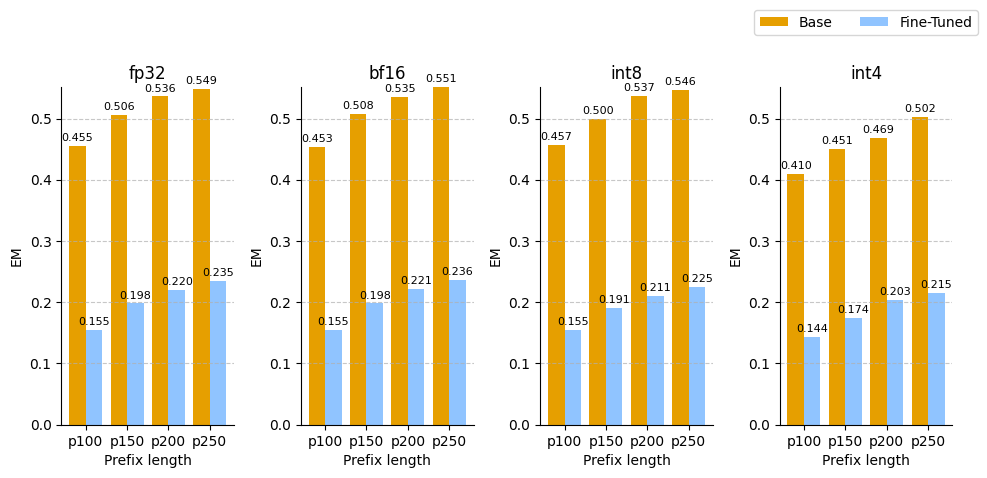

In [27]:
fig, axes = plt.subplots(1, 4, figsize=(10, 5))  # Increased figure width
axes = axes.flatten()


# Number of bars (prefix lengths)
num_bars = len(df_plen_ep0.index)
bar_width = 0.8

# Define a color palette
labels = ['fp32', 'bf16', 'int8', 'int4']
max_value = max(df_plen_ep0.max().max(), df_plen_ep3.max().max())

# Define positions for the bars
bar_positions = np.arange(num_bars)  # x positions for bars

for i, label in enumerate(labels):
    ax = axes[i]

    # Define width for each group
    width = bar_width / 2  # Since there are two groups for each label (ptrain and ftune)

    # Positions for the bars in this group
    positions_ep0 = bar_positions - width / 2  # center align ptrain bars
    positions_ep3 = bar_positions + width / 2  # center align ftune bars

    bars_ep0 = ax.bar(positions_ep0, df_plen_ep0[label], width, label='Base', color='#E69F00')
    bars_ep3 = ax.bar(positions_ep3, df_plen_ep3[label], width, label='Fine-Tuned', color='#90C4FF')

    # Add value labels on top of bars
    for j, bar in enumerate(bars_ep0):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

    for j, bar in enumerate(bars_ep3):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

    # Hide all but the bottom spines (axis lines)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

    ax.set_xlabel('Prefix length')
    ax.set_ylabel('EM')
    ax.set_title(f'{label}')

    #ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2)

    # Set the same y-axis limit
    ax.set_ylim(0, max_value)

    # Set x-ticks to the center of the bars
    ax.set_xticks(bar_positions)
    ax.set_xticklabels(df_plen_ep0.index)

    # Optional grid
    ax.grid(axis='y', linestyle='--', alpha=0.7)

#plt.legend(bbox_to_anchor=(1, 1))
#plt.legend(loc='upper left', bbox_to_anchor=(-2.4, 1.3), ncol=2)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=2)
plt.tight_layout()
plt.show()
fig.savefig('./quant_attack_forget_plen.pdf', format='pdf')

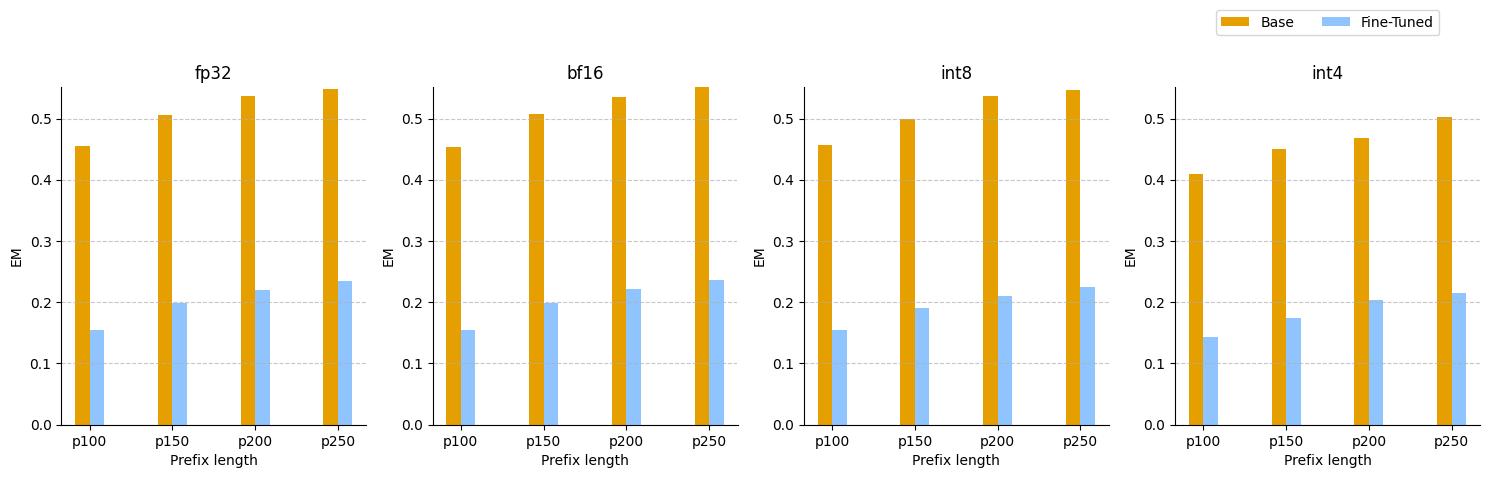

In [28]:


fig, axes = plt.subplots(1, 4, figsize=(15, 5))  # Increased figure width
axes = axes.flatten()


# Number of bars (prefix lengths)
num_bars = len(df_plen_ep0.index)
bar_width = 0.35

# Define a color palette
labels = ['fp32', 'bf16', 'int8', 'int4']
max_value = max(df_plen_ep0.max().max(), df_plen_ep3.max().max())

# Define positions for the bars
bar_positions = np.arange(num_bars)  # x positions for bars

for i, label in enumerate(labels):
    ax = axes[i]

    # Define width for each group
    width = bar_width / 2  # Since there are two groups for each label (ptrain and ftune)

    # Positions for the bars in this group
    positions_ep0 = bar_positions - width / 2  # center align ptrain bars
    positions_ep3 = bar_positions + width / 2  # center align ftune bars

    ax.bar(positions_ep0, df_plen_ep0[label], width, label='Base', color='#E69F00')
    ax.bar(positions_ep3, df_plen_ep3[label], width, label='Fine-Tuned', color='#90C4FF')

    # Hide all but the bottom spines (axis lines)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

    ax.set_xlabel('Prefix length')
    ax.set_ylabel('EM')
    ax.set_title(f'{label}')

    #ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2)

    # Set the same y-axis limit
    ax.set_ylim(0, max_value)

    # Set x-ticks to the center of the bars
    ax.set_xticks(bar_positions)
    ax.set_xticklabels(df_plen_ep0.index)

    # Optional grid
    ax.grid(axis='y', linestyle='--', alpha=0.7)

#plt.legend(bbox_to_anchor=(1, 1))
#plt.legend(loc='upper left', bbox_to_anchor=(-2.4, 1.3), ncol=2)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=2)
plt.tight_layout()
plt.show()
fig.savefig('./base-quant_attack_forget_plen.pdf', format='pdf')

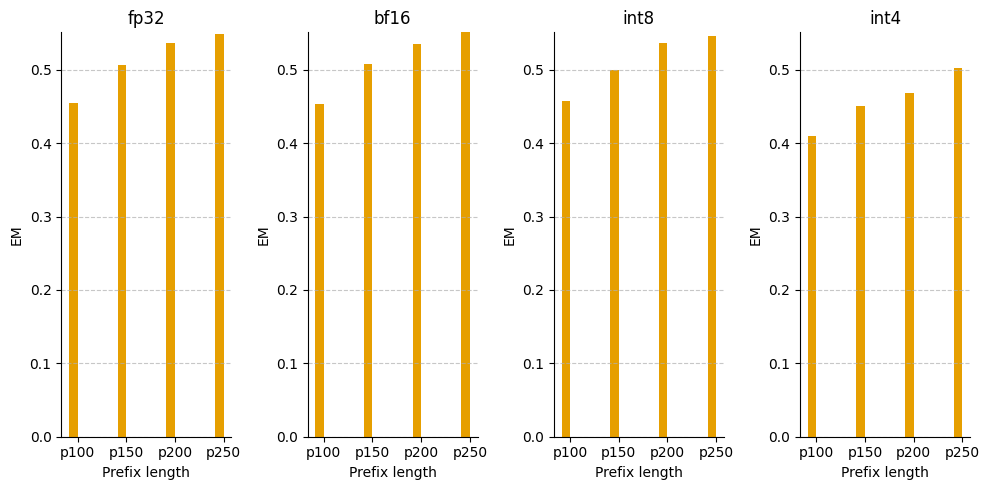

In [29]:
fig, axes = plt.subplots(1, 4, figsize=(10, 5))  # Increased figure width
axes = axes.flatten()


# Number of bars (prefix lengths)
num_bars = len(df_plen_ep0.index)
bar_width = 0.35

# Define a color palette
labels = ['fp32', 'bf16', 'int8', 'int4']
max_value = max(df_plen_ep0.max().max(), df_plen_ep3.max().max())

# Define positions for the bars
bar_positions = np.arange(num_bars)  # x positions for bars

for i, label in enumerate(labels):
    ax = axes[i]

    # Define width for each group
    width = bar_width / 2  # Since there are two groups for each label (ptrain and ftune)

    # Positions for the bars in this group
    positions_ep0 = bar_positions - width / 2  # center align ptrain bars
    # positions_ep3 = bar_positions + width / 2  # center align ftune bars

    ax.bar(positions_ep0, df_plen_ep0[label], width, label='Base', color='#E69F00')
    #ax.bar(positions_ep3, df_plen_ep3[label], width, label='Fine-Tuned', color='#90C4FF')

    # Hide all but the bottom spines (axis lines)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

    ax.set_xlabel('Prefix length')
    ax.set_ylabel('EM')
    ax.set_title(f'{label}')

    #ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2)

    # Set the same y-axis limit
    ax.set_ylim(0, max_value)

    # Set x-ticks to the center of the bars
    ax.set_xticks(bar_positions)
    ax.set_xticklabels(df_plen_ep0.index)

    # Optional grid
    ax.grid(axis='y', linestyle='--', alpha=0.7)

#plt.legend(bbox_to_anchor=(1, 1))
#plt.legend(loc='upper left', bbox_to_anchor=(-2.4, 1.3), ncol=2)
#plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=2)
plt.tight_layout()
plt.show()
fig.savefig('./quant_attack_forget_plen_pre.pdf', format='pdf')